## Embeddings of BE1 

In [2]:
from pathlib import Path
import numpy as np
from scipy.stats import mode
import scanpy as sc
import warnings
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
import sys
import scgpt as scg
import os
import matplotlib.pyplot as plt
#sys.path.insert(0, "../")
# sys.path.insert(0, "../../")

# extra dependency for similarity search
try:
    import faiss

    faiss_imported = True
except ImportError:
    faiss_imported = False
    print(
        "faiss not installed! We highly recommend installing it for fast similarity search."
    )
    print("To install it, see https://github.com/facebookresearch/faiss/wiki/Installing-Faiss")

warnings.filterwarnings("ignore", category=ResourceWarning)

/software/envs/micromamba/envs/nw-scGPTv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


To check the directory (and to modify use %cd and other linux comands) both works

In [7]:
# %pwd
# os.getcwd()

'/home/revalescente/repos/scFound_bench/py_scripts/zero_shot_annotation'

### Read the dataset

In [3]:
model_dir = Path("/projects/shared/intronic_bam/scGPT_supplements/save/scGPT_human")
train_be1 = sc.read_h5ad('/projects/shared/intronic_bam/datasets/anndata/train_BE1_sce.h5ad')
test_be1 = sc.read_h5ad('/projects/shared/intronic_bam/datasets/anndata/test_BE1_sce.h5ad')

cell_type_key = "Sample"
gene_col = "gene_names" # name of the vector in the anndata.var with the gene names 

In [13]:
train_be1

AnnData object with n_obs × n_vars = 20397 × 36753
    obs: 'Sample', 'Barcode', 'sum', 'detected', 'subsets_Mito_sum', 'subsets_Mito_detected', 'subsets_Mito_percent', 'total', 'discard', 'is_train'
    var: 'ID', 'Symbol', 'Type', 'gene_names', 'id_in_vocab'
    uns: 'Samples', 'log1p'
    layers: 'counts'

In [5]:
train_be1.X = train_be1.layers['counts']


sc.pp.normalize_total(train_be1, target_sum=1e4)
sc.pp.log1p(train_be1)

In [9]:
train_be1.X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 48941124 stored elements and shape (20397, 36753)>

Embed the train and test dataset

In [26]:
ref_embed_adata = scg.tasks.embed_data(
    train_be1,
    model_dir,
    gene_col=gene_col,
    batch_size=64
)

scGPT - INFO - match 24288/36753 genes in vocabulary of size 60697.


/software/envs/micromamba/envs/nw-scGPTv2/lib/python3.11/site-packages/scgpt/model/model.py:70: UserWarning: flash-attn is not installed, using pytorch transformer instead. Set use_fast_transformer=False to avoid this warning. Installing flash-attn is highly recommended.
  warnings.warn(
/software/envs/micromamba/envs/nw-scGPTv2/lib/python3.11/site-packages/scgpt/tasks/cell_emb.py:120: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=True):
Embedding cells: 100%|██████████| 319/319 [01:25<00:00,  3.73it/s]
/software/envs/micromamba/envs/nw-scGPTv2/lib/python3.11/site-packages/scgpt/tasks/cell_emb.py:279: ImplicitModificationWarning: Setting element `.obsm['X_scGPT']` of view, initializing view as actual.
  adata.obsm["X_scGPT"] = cell_embeddings


In [10]:
ref_embed_adata

AnnData object with n_obs × n_vars = 20397 × 24288
    obs: 'Sample', 'Barcode', 'sum', 'detected', 'subsets_Mito_sum', 'subsets_Mito_detected', 'subsets_Mito_percent', 'total', 'discard', 'is_train'
    var: 'ID', 'Symbol', 'Type', 'gene_names', 'id_in_vocab'
    uns: 'Samples', 'log1p'
    obsm: 'X_scGPT'
    layers: 'counts'

# Visualize the embeddings

In [25]:
ref_embed_adata.obsm['X_scGPT']

array([[ 0.03120827,  0.04186928,  0.01948739, ...,  0.00197244,
        -0.00020588,  0.00529691],
       [ 0.0172862 ,  0.03210142, -0.0019223 , ..., -0.01404612,
        -0.00415241,  0.0031195 ],
       [ 0.0303533 ,  0.02576175,  0.01780598, ..., -0.00990707,
         0.00380056,  0.01283113],
       ...,
       [ 0.03620373,  0.03835387,  0.00843319, ..., -0.00160882,
         0.00438772,  0.00443633],
       [ 0.00154788,  0.03189121,  0.00632008, ..., -0.01519573,
        -0.02182934,  0.01491941],
       [ 0.02287142,  0.03929218,  0.00385603, ..., -0.00349624,
         0.00234224,  0.00965507]], shape=(20397, 512), dtype=float32)

I0000 00:00:1783511434.614373  113256 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783511434.843705  113256 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783511436.699615  113256 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


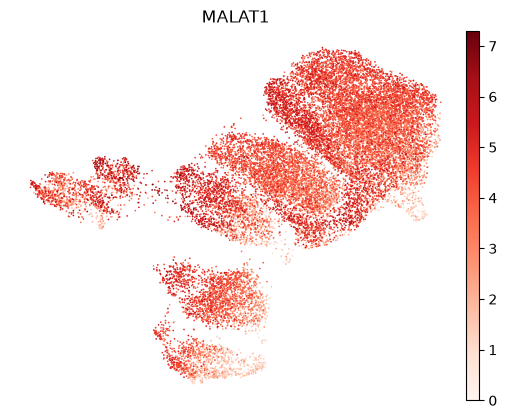

In [12]:
# Calcolo vicini e UMAP
sc.pp.neighbors(ref_embed_adata, use_rep="X_scGPT")
sc.tl.umap(ref_embed_adata)

In [21]:
import matplotlib.pyplot as plt
import scanpy as sc

# 1. Crea una figura con 1 riga e 2 colonne
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# 2. Primo plot (MALAT1) sul primo asse (axes[0])
# NOTA: 'color' deve essere una stringa, NON una lista
sc.pl.umap(
    ref_embed_adata,
    color="MALAT1",  # <--- Corretto: stringa invece di lista
    gene_symbols="Symbol",
    frameon=False,
    cmap="Reds",
    ax=axes[0],
    show=False,
    size=10
)

# 3. Secondo plot (Cell Type) sul secondo asse (axes[1])
# Assicurati che cell_type_key sia una stringa singola
sc.pl.umap(
    ref_embed_adata,
    color=cell_type_key,
    frameon=False,
    ax=axes[1],
    show=False,
    size=10
)

# 4. Ottimizza lo spazio tra i due grafici per evitare sovrapposizioni
plt.tight_layout()

# 5. Salva il risultato combinato usando l'oggetto 'fig'
fig.savefig(
    "umap_MALAT1_e_cell_type.png",
    dpi=300,
    bbox_inches="tight",
)

plt.close(fig)

# Reference mapping and transfer the annotation

Function to use when faiss is not installed

In [9]:
# Those functions are only used when faiss is not installed
def l2_sim(a, b):
    sims = -np.linalg.norm(a - b, axis=1)
    return sims

def get_similar_vectors(vector, ref, top_k=10):
        # sims = cos_sim(vector, ref)
        sims = l2_sim(vector, ref)
        
        top_k_idx = np.argsort(sims)[::-1][:top_k]
        return top_k_idx, sims[top_k_idx]

We run the reference mapping using cell-level majority voting. You may adjust the k parameter to control the number of nearest neighbors to consider for voting.

In [10]:
ref_cell_embeddings = ref_embed_adata.obsm["X_scGPT"]
test_embed = test_embed_adata.obsm["X_scGPT"]

In [11]:
kappa = 10 # number of neighbors

if faiss_imported:
    index = faiss.IndexFlatL2(ref_cell_embeddings.shape[1])
    index.add(ref_cell_embeddings)

    # Query dataset, k - number of closest elements (returns 2 numpy arrays)
    distances, labels = index.search(test_embed, k)

    sim_list = distances
idx_list=[i for i in range(test_embed.shape[0])]
preds = []
for k in idx_list:
    if faiss_imported:
        idx = labels[k]
    else:
        idx, sim = get_similar_vectors(test_embed[k][np.newaxis, ...], ref_cell_embeddings, kappa)
    pred = ref_embed_adata.obs[cell_type_key][idx].value_counts()
    preds.append(pred.index[0])
gt = test_be1.obs[cell_type_key].to_numpy()

In [12]:
res_dict = {
    "accuracy": accuracy_score(gt, preds),
    "precision": precision_score(gt, preds, average="macro"),
    "recall": recall_score(gt, preds, average="macro"),
    "macro_f1": f1_score(gt, preds, average="macro"),
}

res_dict

{'accuracy': 0.8497308441186576,
 'precision': 0.8948397435314158,
 'recall': 0.8856559334526081,
 'macro_f1': 0.889480590826597}

In [37]:
from collections import Counter

Counter(preds)

Counter({'CD4 T-cells': 1090,
         'Monocytes CD14+': 728,
         'Natural Killers': 336,
         'B-cells': 99,
         'Monocytes CD16+': 40,
         'Precursors': 39,
         'NA': 26,
         'CD8 T-cells': 23,
         'T-cells': 1})

In [38]:
Counter(gt)

Counter({'CD4 T-cells': 978,
         'Monocytes CD14+': 716,
         'Natural Killers': 318,
         'CD8 T-cells': 119,
         'B-cells': 104,
         'NA': 50,
         'Monocytes CD16+': 45,
         'Precursors': 38,
         'T-cells': 14})

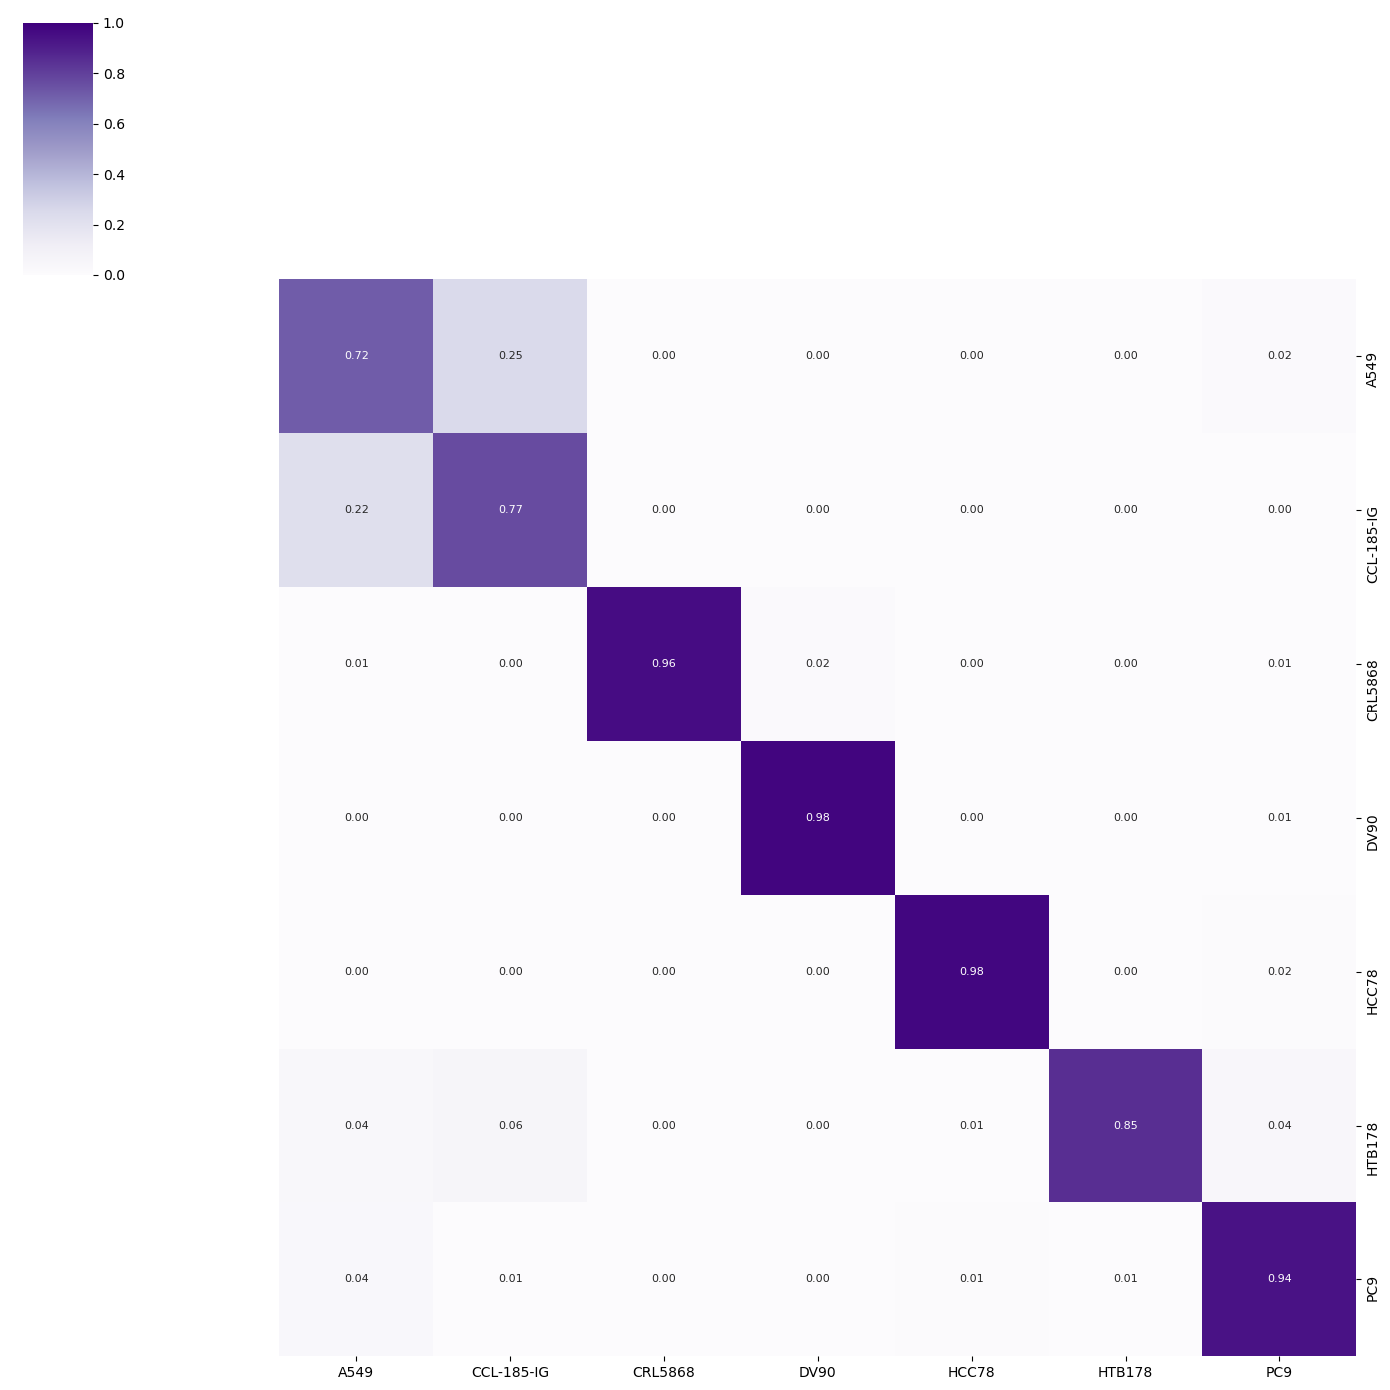

In [13]:
y_true = gt
y_pred = preds
cell_type_list = np.unique(y_true)
matrix = confusion_matrix(y_true, y_pred, labels=cell_type_list)
matrix = matrix.astype("float") / matrix.sum(axis=1)[:, np.newaxis]

df = pd.DataFrame(matrix, index=cell_type_list[:matrix.shape[0]], columns=cell_type_list[:matrix.shape[1]])

ax = sns.clustermap(df,  
                    cmap='Purples',
                    annot=True ,fmt=".2f", 
                    annot_kws={'size': 8}, 
                    vmin=0, 
                    vmax=1,
                    row_cluster=False, 
                    col_cluster=False, 
                    figsize=(14, 14))